In [1]:
import os
import cv2
import numpy as np
from PIL import Image
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Experimento Com Arquitetura ResNet18

## Objetivo

Este experimento avalia o desempenho de uma arquitetura de Deep Learning intermediária (ResNet18) na tarefa de classificação da posição de radiografias torácicas. O objetivo é comparar o desempenho de arquiteturas mais simples com arquiteturas profundas como ResNet50, utilizada no artigo original do PadChest.

A ResNet18 foi escolhida por possuir:
- menor profundidade
- menor custo computacional
- menor risco de overfitting
- boa capacidade de generalização

Este modelo serve como baseline intermediário entre redes simples e redes profundas.

## Função de carregamento que usa OpenCV para evitar o bug da Pillow

In [2]:
def opencv_loader(path):
    img_np = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return Image.fromarray(img_np)

## Pipeline de pré-processamento e data augmentation

1. As radiografias foram convertidas para escala de cinza, pois são imagens naturalmente monocromáticas. Assim, o uso de um único canal é suficiente para representar a informação visual relevante, além de reduzir o custo computacional.

2. Todas as imagens foram redimensionadas para `150 x 150` pixels, padronizando o formato de entrada da rede neural.

3. Em seguida, as imagens foram convertidas para tensores e normalizadas com média `0.5` e desvio padrão `0.5`.

## Aumento de dados no conjunto de treinamento

Para o conjunto de treinamento, aplicamos técnicas leves de data augmentation com o objetivo de aumentar a robustez do modelo e reduzir overfitting.

Foram utilizadas as seguintes transformações:

- variação de brilho e contraste
- rotação aleatória de até 3 graus
- pequenas translações de até 3% na horizontal e vertical

Essas transformações foram escolhidas por representarem pequenas variações plausíveis no processo de aquisição das imagens, sem comprometer a estrutura anatômica principal.

In [3]:
IMAGE_SIZE = 150

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    transforms.RandomRotation(degrees=3),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Carrega dados e prepara DataLoaders

In [4]:
data_dir = "data_split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

train_dataset = ImageFolder(train_dir, transform=train_transform, loader=opencv_loader)
val_dataset = ImageFolder(val_dir, transform=test_val_transform, loader=opencv_loader)
test_dataset = ImageFolder(test_dir, transform=test_val_transform, loader=opencv_loader)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['frente', 'lado']


## Verificação visual

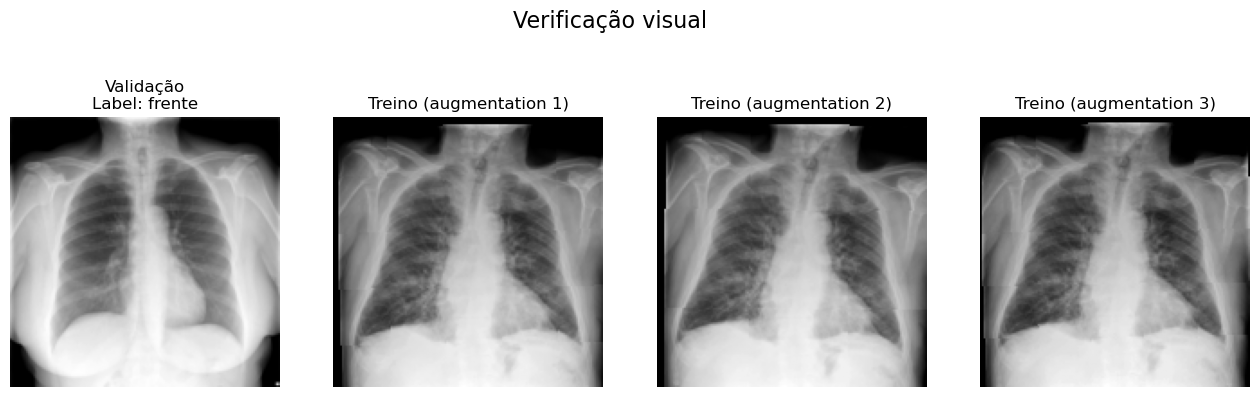

In [5]:
def imshow(tensor, title=None):
    image = tensor.cpu().clone()  
    
    mean = 0.5
    std = 0.5
    image = image * std + mean
    
    image = image.numpy()
    
    image = np.squeeze(image, axis=0)
    
    image = np.clip(image, 0, 1)

    plt.imshow(image, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')


val_image, val_label_idx = val_dataset[0]
val_label_name = val_dataset.classes[val_label_idx]

train_image_1, train_label_idx = train_dataset[0]
train_image_2, _ = train_dataset[0]
train_image_3, _ = train_dataset[0]
train_label_name = train_dataset.classes[train_label_idx]

plt.figure(figsize=(16, 5))
plt.suptitle("Verificação visual", fontsize=16)

plt.subplot(1, 4, 1)
imshow(val_image, title=f"Validação\nLabel: {val_label_name}")

plt.subplot(1, 4, 2)
imshow(train_image_1, title="Treino (augmentation 1)")

plt.subplot(1, 4, 3)
imshow(train_image_2, title="Treino (augmentation 2)")

plt.subplot(1, 4, 4)
imshow(train_image_3, title="Treino (augmentation 3)")

plt.show()

## Distribuição de classes (train set)

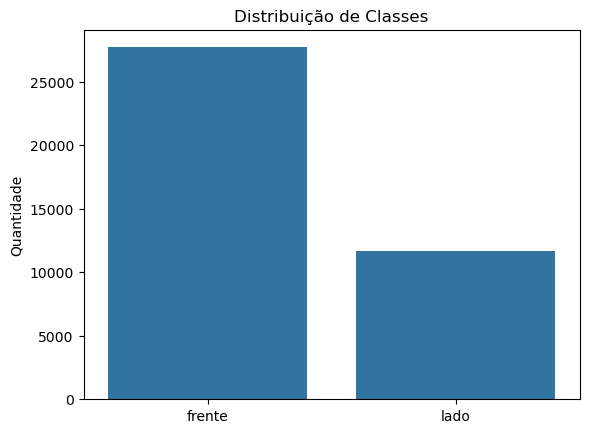

In [6]:
label_counts = Counter(train_dataset.targets)
sns.barplot(x=train_dataset.classes, y=[label_counts[i] for i in range(len(train_dataset.classes))])
plt.title("Distribuição de Classes")
plt.ylabel("Quantidade")
plt.show()

## Arquitetura da rede neural

Foi utilizada a arquitetura ResNet18, uma rede convolucional profunda baseada em conexões residuais que permitem treinar redes mais profundas evitando o problema de vanishing gradients.

### Transfer learning

O modelo foi inicializado com pesos pré-treinados no dataset ImageNet. Essa estratégia permite aproveitar características visuais gerais já aprendidas, acelerando a convergência e melhorando a generalização.

### Adaptação para imagens médicas

Como radiografias são imagens monocromáticas, a primeira camada convolucional foi modificada para aceitar apenas 1 canal de entrada em vez dos 3 canais RGB originais.

Essa modificação:
- reduz o número de parâmetros
- melhora a adequação ao domínio médico
- evita redundância de informação

### Adaptação da camada de classificação

A camada final foi substituída por uma nova camada totalmente conectada com **2 saídas**, correspondendo às classes:
- Frente
- Lado

Também foi adicionado um dropout de 20% para reduzir overfitting.

In [7]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, 2)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

## Função de perda e tratamento do desbalanceamento de classes

Durante a análise do dataset foi observado um desbalanceamento entre as classes. Este tipo de problema pode levar o modelo a favorecer a classe majoritária, prejudicando a capacidade de generalização.

Para mitigar esse efeito, foram calculados pesos proporcionais à frequência inversa das classes utilizando `compute_class_weight`.

Esses pesos foram incorporados à função de perda CrossEntropyLoss, fazendo com que erros na classe minoritária tenham maior penalização durante o treinamento.

In [8]:
all_labels = train_dataset.targets  

class_weights = compute_class_weight(
    class_weight='balanced',       
    classes=np.unique(all_labels), 
    y=all_labels                    
)

class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

print("Pesos das classes:", class_weights)

Pesos das classes: tensor([0.7111, 1.6841], device='cuda:0')


In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Configuração e estratégia de treinamento

O treinamento foi realizado utilizando a função de perda CrossEntropyLoss com pesos de classe, de forma a reduzir o impacto do desbalanceamento entre as categorias.

Como otimizador, foi utilizado o **Adam** com taxa de aprendizado inicial de `1e-3`, devido à sua boa estabilidade e rápida convergência em problemas de Deep Learning.

Além disso, foi empregado o scheduler **ReduceLROnPlateau**, que reduz automaticamente a taxa de aprendizado quando a acurácia de validação deixa de melhorar. Neste experimento, o learning rate é multiplicado por `0.3` após `2` épocas sem ganho de desempenho, com valor mínimo de `1e-6`.

Também foi adotada a estratégia de **early stopping**, com paciência de `5` épocas, para interromper o treinamento quando não houver melhora na validação. Isso ajuda a evitar overfitting e reduz treinamento desnecessário.

O modelo foi treinado por até `20` épocas, sempre monitorando:
- loss de treinamento
- loss de validação
- acurácia de treinamento
- acurácia de validação

Ao final de cada época, o modelo com melhor acurácia de validação é salvo para posterior avaliação.

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=2, min_lr=1e-6
)

best_val_acc = 0
early_stop_counter = 0
PATIENCE = 5
EPOCHS = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()  
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Treino]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()    
        outputs = model(images)   
        loss = criterion(outputs, labels)  
        loss.backward()          
        optimizer.step()          

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval() 
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Validação]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    val_loss /= total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)                  
    current_lr = scheduler.get_last_lr()[0] 

    print(f"\nEpoch {epoch+1}/{EPOCHS}  LR: {current_lr:.6f}  "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_split.pth")
        print("📌 Melhor modelo salvo.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("⏹️ Early stopping acionado.")
            break

print("✅ Treinamento finalizado.")

model.load_state_dict(torch.load("resnet18_split.pth"))

Epoch 1/20 [Validação]: 100%|██████████████████████████████████████████████████████████| 68/68 [10:55<00:00,  9.63s/it]



Epoch 1/20  LR: 0.001000  Train Loss: 0.0261, Acc: 0.9952  Val Loss: 0.0161, Acc: 0.9978
📌 Melhor modelo salvo.


Epoch 2/20 [Validação]: 100%|██████████████████████████████████████████████████████████| 68/68 [10:52<00:00,  9.60s/it]



Epoch 2/20  LR: 0.001000  Train Loss: 0.0181, Acc: 0.9975  Val Loss: 0.0203, Acc: 0.9978


Epoch 3/20 [Validação]: 100%|██████████████████████████████████████████████████████████| 68/68 [09:55<00:00,  8.76s/it]


...


Epoch 7/20  LR: 0.000300  Train Loss: 0.0135, Acc: 0.9978  Val Loss: 0.0124, Acc: 0.9979


Epoch 8/20 [Validação]: 100%|██████████████████████████████████████████████████████████| 68/68 [11:06<00:00,  9.80s/it]


Epoch 8/20  LR: 0.000300  Train Loss: 0.0125, Acc: 0.9977  Val Loss: 0.0136, Acc: 0.9978
⏹️ Early stopping acionado.
✅ Treinamento finalizado.



C:\Users\Disas\AppData\Local\Temp\ipykernel_23848\2355057277.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet18_split.pth"))


<All keys matched successfully>

## Análise das curvas de treinamento

Os gráficos mostram a evolução da loss e da acurácia ao longo das épocas para os conjuntos de treinamento e validação.

### Convergência do modelo

Observa-se uma redução consistente da loss de treinamento, indicando que o modelo conseguiu aprender padrões relevantes da tarefa. A loss de validação acompanha essa tendência, sugerindo boa capacidade de generalização.

### Overfitting

Não há evidência significativa de overfitting, pois:

- As curvas de treino e validação permanecem próximas
- A acurácia de validação acompanha a de treinamento
- A loss de validação não apresenta aumento significativo

Isso indica que o modelo não está apenas memorizando os dados de treino.

### Desempenho obtido

A acurácia alcançada (~99.7%) sugere que a tarefa de classificação entre imagens frontais e laterais é relativamente simples para a arquitetura utilizada.

Esse resultado reforça a hipótese do trabalho de que arquiteturas menores podem ser suficientes para tarefas de menor complexidade.

### Estabilidade do treinamento

Após poucas épocas, o modelo já apresenta convergência, com pequenas variações posteriores. Isso indica que o problema possui separabilidade clara entre as classes.

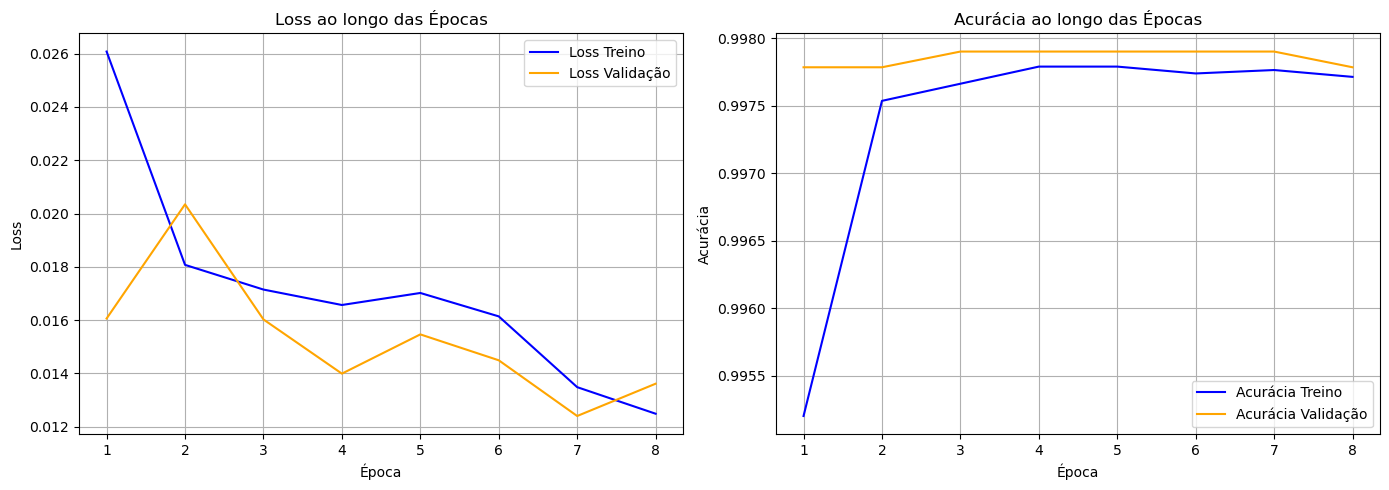

In [11]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Loss Treino', color='blue')
plt.plot(epochs_range, val_losses, label='Loss Validação', color='orange')
plt.title("Loss ao longo das Épocas")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Acurácia Treino', color='blue')
plt.plot(epochs_range, val_accuracies, label='Acurácia Validação', color='orange')
plt.title("Acurácia ao longo das Épocas")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Avaliação no Conjunto de Teste

              precision    recall  f1-score   support

      frente       1.00      1.00      1.00      5990
        lado       1.00      1.00      1.00      2576

    accuracy                           1.00      8566
   macro avg       1.00      1.00      1.00      8566
weighted avg       1.00      1.00      1.00      8566



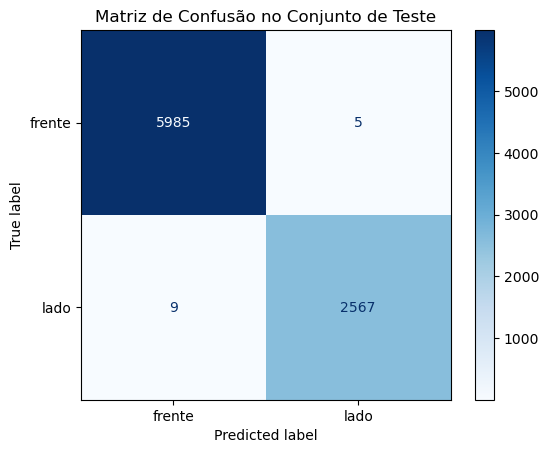

In [12]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  
        y_true.extend(labels.cpu().numpy())    
        y_pred.extend(predicted.cpu().numpy()) 

class_names = ['frente', 'lado']
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão no Conjunto de Teste")
plt.show()